<a href="https://colab.research.google.com/github/os1187/EDA-E1-26-27/blob/main/Assessment_6_25BAI0058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Coffee Shop Sales.xlsx - Transactions.csv")


In [3]:
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()


First 5 rows:
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1         1/1/2023          7:06:11                2   
1               2         1/1/2023          7:08:56                2   
2               3         1/1/2023          7:14:04                2   
3               4         1/1/2023          7:20:24                1   
4               5         1/1/2023          7:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [5]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [6]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
       transaction_id  transaction_qty       store_id     product_id  \
count   149116.000000    149116.000000  149116.000000  149116.000000   
mean     74737.371872         1.438276       5.342063      47.918607   
std      43153.600016         0.542509       2.074241      17.930020   
min          1.000000         1.000000       3.000000       1.000000   
25%      37335.750000         1.000000       3.000000      33.000000   
50%      74727.500000         1.000000       5.000000      47.000000   
75%     112094.250000         2.000000       8.000000      60.000000   
max     149456.000000         8.000000       8.000000      87.000000   

          unit_price  
count  149116.000000  
mean        3.382219  
std         2.658723  
min         0.800000  
25%         2.500000  
50%         3.000000  
75%         3.750000  
max        45.000000  


In [7]:
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
transaction_id      149116
transaction_date       181
transaction_time     25762
transaction_qty          6
store_id                 3
store_location           3
product_id              80
unit_price              41
product_category         9
product_type            29
product_detail          80
dtype: int64


In [8]:
df["sales"] = df["transaction_qty"] * df["unit_price"]

print("\nTotal Sales:")
print(df["sales"].sum())


Total Sales:
698812.3300000002



Sales by Product Category:
product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: sales, dtype: float64


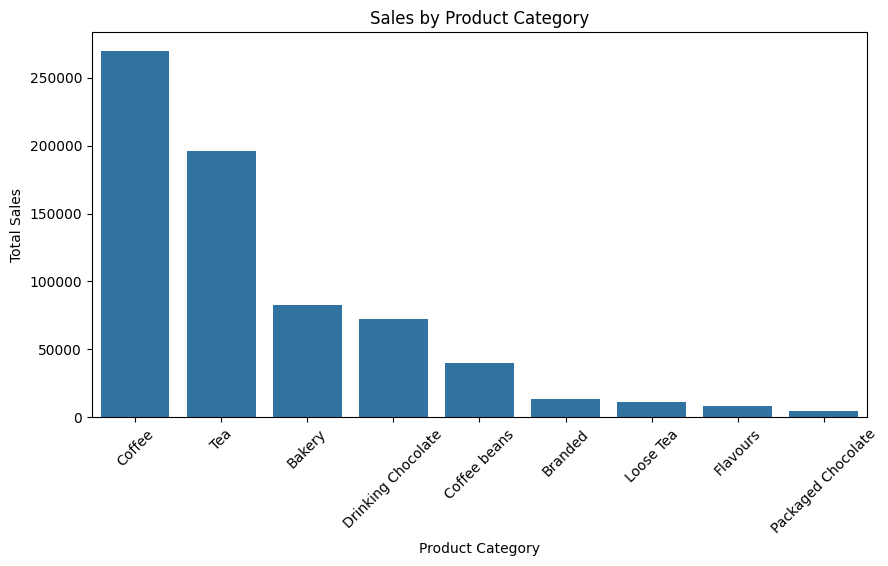

In [9]:
category_sales = df.groupby("product_category")["sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Product Category:")
print(category_sales)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


Sales by Store Location:
store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: sales, dtype: float64


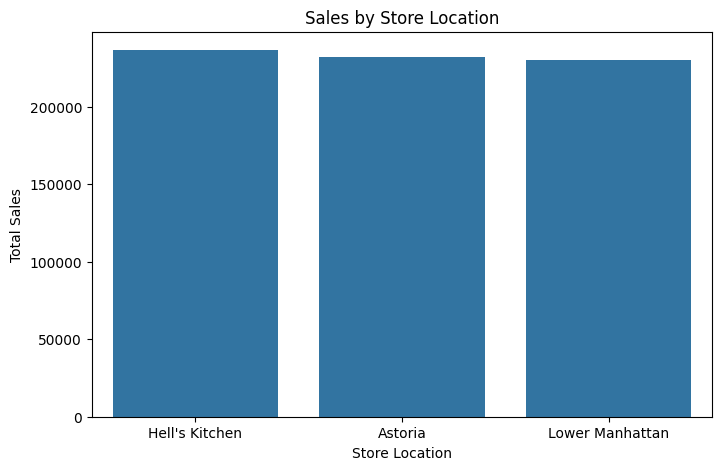

In [10]:
location_sales = df.groupby("store_location")["sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Store Location:")
print(location_sales)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=location_sales.index,
    y=location_sales.values
)
plt.title("Sales by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Sales")
plt.show()


Top 10 Products by Sales:
product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: sales, dtype: float64


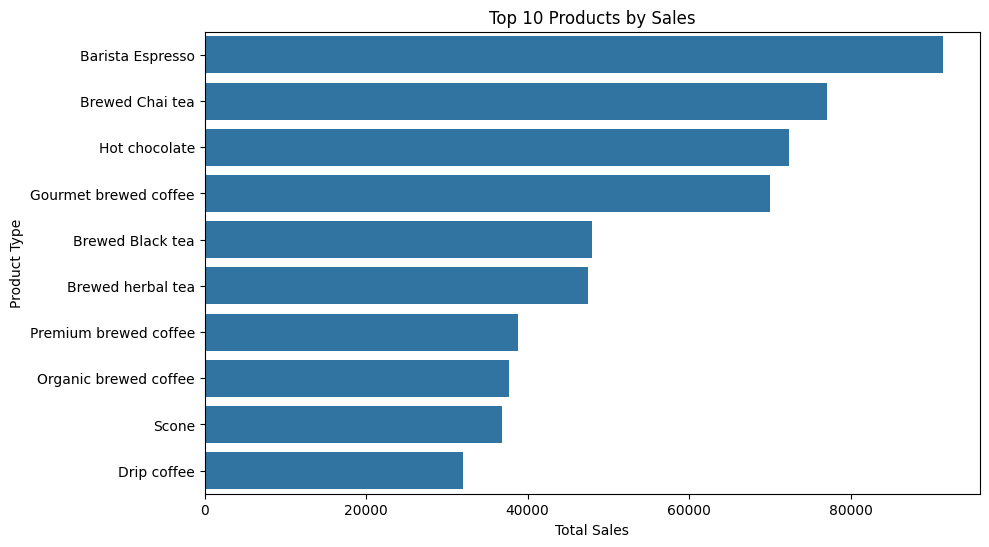

In [11]:
top_products = df.groupby("product_type")["sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Products by Sales:")
print(top_products)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Type")
plt.show()

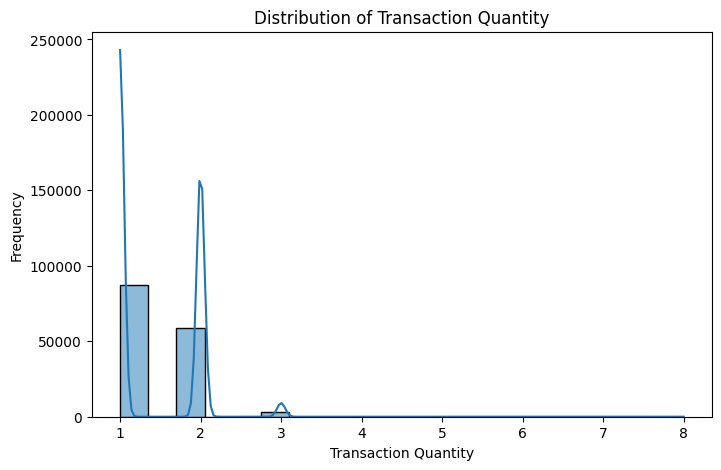

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["transaction_qty"], bins=20, kde=True)
plt.title("Distribution of Transaction Quantity")
plt.xlabel("Transaction Quantity")
plt.ylabel("Frequency")
plt.show()

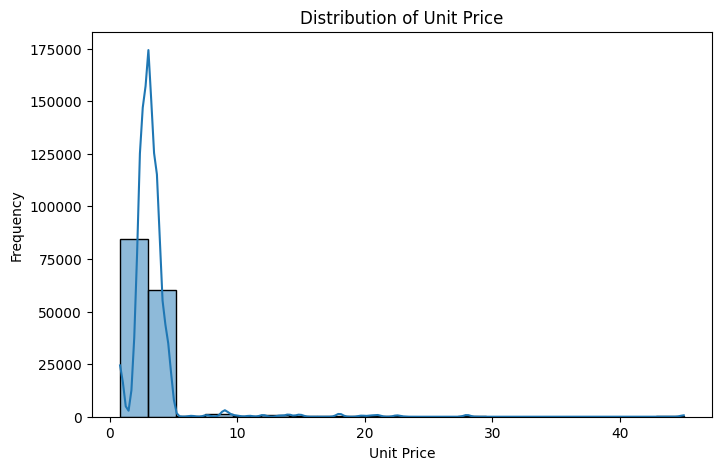

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["unit_price"], bins=20, kde=True)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()


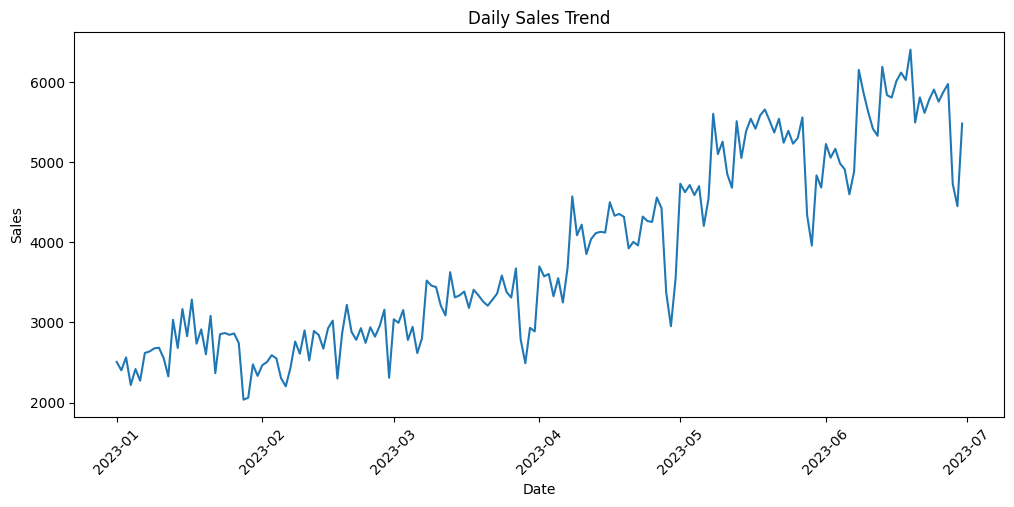

In [14]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

daily_sales = df.groupby("transaction_date")["sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

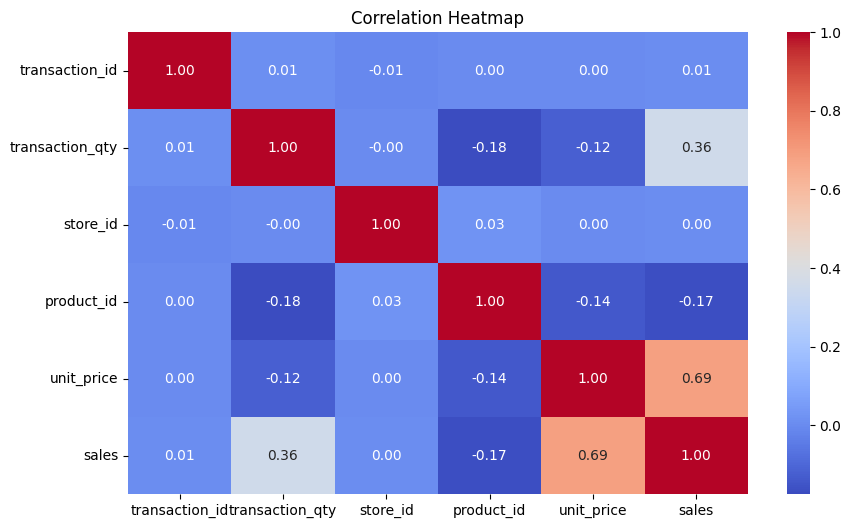

In [15]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

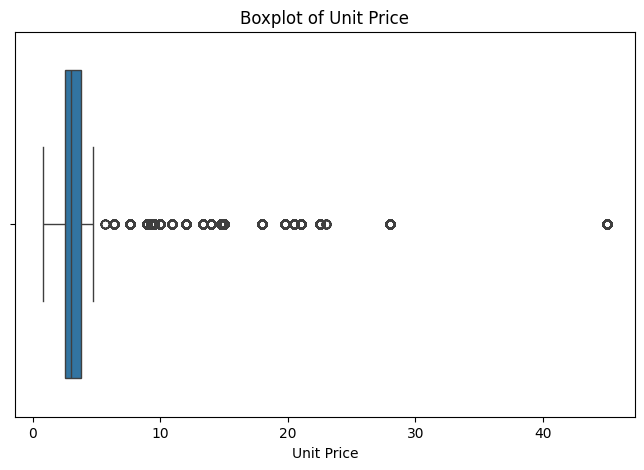

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["unit_price"])
plt.title("Boxplot of Unit Price")
plt.xlabel("Unit Price")
plt.show()

In [17]:
print("Total number of transactions:", len(df))
print("Total sales:", df["sales"].sum())
print("Average transaction quantity:", df["transaction_qty"].mean())
print("Average unit price:", df["unit_price"].mean())

print("\nBest performing product category:")
print(category_sales.idxmax())

print("\nBest performing store location:")
print(location_sales.idxmax())

print("\nBest selling product type:")
print(top_products.idxmax())

Total number of transactions: 149116
Total sales: 698812.3300000002
Average transaction quantity: 1.438276241315486
Average unit price: 3.382219413074385

Best performing product category:
Coffee

Best performing store location:
Hell's Kitchen

Best selling product type:
Barista Espresso
